In [1]:
import pandas as pd
import seaborn as sns

sns.set_theme()

# 1. Load your financial data
# Replace 'financial_returns.csv' with your actual file path (CSV, Excel, etc.)
# We assume dates are in the first column and set them as the index

df = pd.read_csv('./data/concat_hf_data.csv', parse_dates=True).set_index('date')
df.index = pd.to_datetime(df.index)

df = df.drop(columns=['sp500'], axis=1)
# df = df[['bam', 'four_world', 'quantstream', 'm1', 'vadantia', 'sp500', 'arr']]
# 2. Compute the correlation matrix
# 'min_periods' ensures we have at least N overlapping data points 
# to trust the correlation score. Adjust this based on your dataset size.
# corr_matrix = df.corr(method='pearson', min_periods=3)

df = df[df.index >= pd.to_datetime('2020-01-01')]

df.head()

,maple_cap,arr,quantstream,tidan,four_world,wizard_quant,global_sigma,m1,vadantia,enko,bam,cambrian,brummer
date,,,,,,,,,,,,,
2020-01-01,NaN,NaN,-0.010088,NaN,0.0215,-0.0022,0.0001,NaN,-0.0033,0.0237,0.0000,0.204,0.0180
2020-02-01,NaN,NaN,-0.035018,NaN,-0.0206,0.0035,0.0119,NaN,0.0185,0.0285,0.0117,0.007,-0.0051
2020-03-01,-0.0200,NaN,-0.072548,NaN,-0.0342,0.0015,0.0126,NaN,0.0262,0.0430,0.0362,-0.036,-0.0446
2020-04-01,0.0272,NaN,0.083602,NaN,0.0196,0.0160,0.0115,NaN,-0.0433,0.0331,0.0321,0.112,0.0001
2020-05-01,0.0004,NaN,0.060922,NaN,0.0157,0.0007,0.0085,NaN,-0.0039,0.0336,0.0386,0.001,0.0581


In [2]:
import numpy as np

# 1. Compute the volatility of each column (standard deviation)
volatilities = df.std()

# 2. Use inverse volatility to compute the weighting
inv_vol = 1.0 / volatilities

def compute_inv_vol_return(row):
    # Get columns that have non-NaN values for this specific row (month)
    valid_cols = row.dropna().index
    if len(valid_cols) == 0:
        return np.nan
    
    # Get the inverse volatility of these existing columns
    valid_inv_vol = inv_vol[valid_cols]
    
    # Normalize these inverse vols to get a weighting that sums to 1
    weights = valid_inv_vol / valid_inv_vol.sum()
    
    # Apply this weighting to the returns to create the portfolio return for this row
    return (row[valid_cols] * weights).sum()

# Apply to each row
portfolio_returns = df.apply(compute_inv_vol_return, axis=1)
portfolio_returns.name = 'Inv_Vol_Portfolio'

# Show the first few rows of the computed portfolio
portfolio_returns.head()

date
2020-01-01    0.011436
2020-02-01    0.001436
2020-03-01   -0.005002
2020-04-01    0.024014
2020-05-01    0.020998
Name: Inv_Vol_Portfolio, dtype: float64

In [ ]:
portfolio_returns

In [4]:
def performance_report(returns, benchmark_returns=None):
    """
    Compute various performance metrics for a return series.
    """

    # print(f"DEBUG : {returns}")
    if benchmark_returns is not None:
        aligned = pd.concat([returns, benchmark_returns], axis=1).dropna()
        print(f"DEBUG : {aligned}")
        ret = aligned.iloc[:, 0]
        bmk = aligned.iloc[:, 1]
    else:
        ret = returns.dropna()
        bmk = None
        
    # print(f"DEBUG : {ret}")
    
    n_months = len(ret)
    # print(f'DEBUG : {n_months}')
    # CAGR
    cum_ret = (1 + ret).prod()
    cagr = cum_ret ** (12 / n_months) - 1
    
    # Mean return (annualized)
    mean_ret = ret.mean() * 12
    
    # Vol (annualized)
    vol = ret.std() * np.sqrt(12)
    
    # Positive number of months
    pos_months = (ret > 0).sum()
    pos_months_pct = pos_months / n_months
    
    # Sharpe ratio (Assuming Risk-Free Rate = 0)
    sharpe = mean_ret / vol if vol != 0 else np.nan
    
    # Max Drawdown
    cum_idx = (1 + ret).cumprod()
    running_max = cum_idx.cummax()
    drawdown = (running_max - cum_idx) / running_max
    max_drawdown = drawdown.max()
    
    # Calmar ratio
    calmar = cagr / max_drawdown if max_drawdown != 0 else np.nan
    corr = bmk.corr(ret)
    metrics = {
        'CAGR': cagr,
        'Ann. Mean Return': mean_ret,
        'Ann. Volatility': vol,
        'Positive Months': pos_months,
        '% Positive Months': pos_months_pct,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_drawdown,
        'Calmar Ratio': calmar,
        'Correlation' : corr
    }
    
    # Upside and Downside capture relative to benchmark
    if bmk is not None:
        # Upside Capture
        up_idx = bmk > 0
        if up_idx.sum() > 0:
            up_port_ret = (1 + ret[up_idx]).prod() - 1
            up_bmk_ret = (1 + bmk[up_idx]).prod() - 1
            metrics['Upside Capture'] = up_port_ret / up_bmk_ret if up_bmk_ret != 0 else np.nan
        else:
            metrics['Upside Capture'] = np.nan
            
        # Downside Capture
        down_idx = bmk < 0
        if down_idx.sum() > 0:
            down_port_ret = (1 + ret[down_idx]).prod() - 1
            down_bmk_ret = (1 + bmk[down_idx]).prod() - 1
            metrics['Downside Capture'] = down_port_ret / down_bmk_ret if down_bmk_ret != 0 else np.nan
        else:
            metrics['Downside Capture'] = np.nan
            
    return pd.Series(metrics)

# Load sp500 for benchmark, align it to our data
all_data = pd.read_csv('./data/concat_hf_data.csv', parse_dates=True).set_index('date')
sp500 = all_data['sp500']
sp500.index = pd.to_datetime(sp500.index)

# Compute report
report = performance_report(portfolio_returns, sp500)
display(pd.DataFrame(report, columns=['Inv_Vol_Portfolio']))

DEBUG :             Inv_Vol_Portfolio     sp500
date                                   
2020-01-01           0.011436 -0.000392
2020-02-01           0.001436 -0.082319
2020-03-01          -0.005002 -0.123513
2020-04-01           0.024014  0.128194
2020-05-01           0.020998  0.047627
...                       ...       ...
2025-12-01           0.007171  0.000612
2026-01-01           0.019246  0.014500
2026-02-01           0.009613 -0.007600
2026-03-01          -0.015571 -0.049795
2026-04-01           0.018970  0.104927

[76 rows x 2 columns]


,Inv_Vol_Portfolio
CAGR,0.146829
Ann. Mean Return,0.138180
Ann. Volatility,0.028404
Positive Months,71.000000
% Positive Months,0.934211
Sharpe Ratio,4.864811
Max Drawdown,0.015571
Calmar Ratio,9.429672
Correlation,0.429720
Upside Capture,0.140407


In [5]:
concat_df = pd.concat([portfolio_returns, sp500], axis=1).dropna()
concat_df.index = pd.to_datetime(concat_df.index)

concat_df[concat_df['sp500'] < concat_df['sp500'].quantile(0.25)].corr()

,Inv_Vol_Portfolio,sp500
Inv_Vol_Portfolio,1.000000,0.408232
sp500,0.408232,1.000000


<Axes: xlabel='Inv_Vol_Portfolio', ylabel='sp500'>

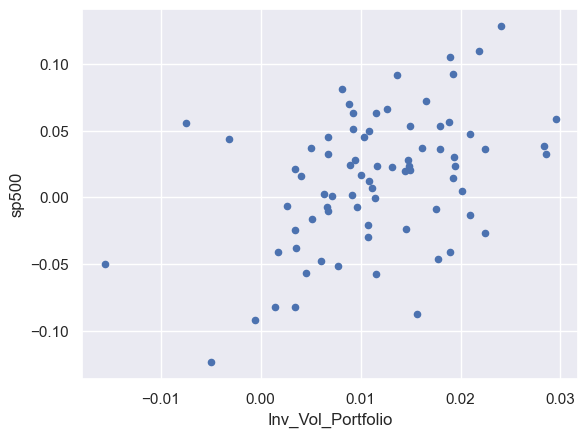

In [6]:
concat_df.plot(kind='scatter', x='Inv_Vol_Portfolio', y='sp500')

In [7]:
concat_df

,Inv_Vol_Portfolio,sp500
date,,
2020-01-01,0.011436,-0.000392
2020-02-01,0.001436,-0.082319
2020-03-01,-0.005002,-0.123513
2020-04-01,0.024014,0.128194
2020-05-01,0.020998,0.047627
...,...,...
2025-12-01,0.007171,0.000612
2026-01-01,0.019246,0.014500
2026-02-01,0.009613,-0.007600


In [8]:
vix = pd.read_csv('./data/hf_returns/vix.csv').set_index('Date')
vix.index.rename('date', inplace=True)
vix.index = pd.to_datetime(vix.index)

vix

,close,diff
date,,
2020-01-01,18.840000,NaN
2020-02-01,40.110001,21.270000
2020-03-01,53.540001,13.430000
2020-04-01,34.150002,-19.389999
2020-05-01,27.510000,-6.640001
...,...,...
2026-01-01,17.440001,2.490001
2026-02-01,19.860001,2.420000
2026-03-01,25.250000,5.389999


<Axes: xlabel='Inv_Vol_Portfolio', ylabel='diff'>

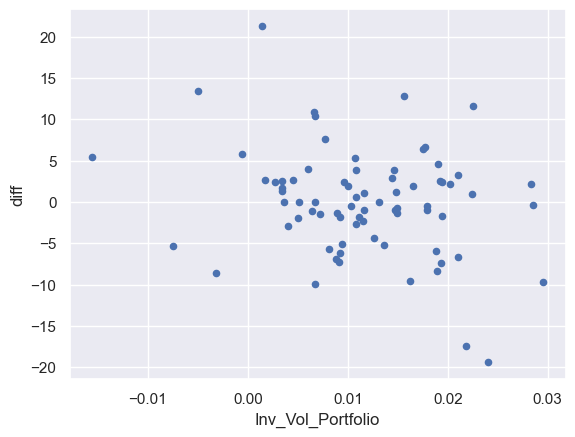

In [9]:
merged_df = pd.merge(vix, concat_df, left_index=True, right_index=True, how='inner')

merged_df.plot(kind='scatter', x='Inv_Vol_Portfolio', y='diff')